In [5]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
experiment_dir = Path("results/47V/experiments/mlp_window_grid")
experiment_dir.resolve()
mlp_trials = pd.read_csv(experiment_dir / "mlp_trials.csv")
mlp_summary = pd.read_csv(experiment_dir / "mlp_configuration_summary.csv")
std_summary = pd.read_csv(experiment_dir / "standard_method_summary.csv")

manifest_path = experiment_dir / "experiment_manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}

print("mlp_trials:", mlp_trials.shape)
print("mlp_summary:", mlp_summary.shape)
print("std_summary:", std_summary.shape)

mlp_trials: (27, 16)
mlp_summary: (1, 16)
std_summary: (27, 16)


In [7]:
window_rows = []

datasets_dir = experiment_dir / "datasets"
for wdir in sorted(datasets_dir.glob("window_*")):
    manifest_path = wdir / "manifest.json"
    if not manifest_path.exists():
        continue
    m = json.loads(manifest_path.read_text(encoding="utf-8"))
    derived = m.get("derived_window", {})
    window_id = int(wdir.name.split("_")[-1])
    before_ns = derived.get("window_before_ns")
    after_ns = derived.get("window_after_ns")
    window_rows.append(
        {
            "window_id": window_id,
            "window_before_ns": before_ns,
            "window_after_ns": after_ns,
            "window_width_ns": None if before_ns is None or after_ns is None else before_ns + after_ns,
            "input_length": m.get("input_length"),
        }
    )

window_df = pd.DataFrame(window_rows).sort_values("window_id")
display(window_df)

KeyError: 'window_id'

In [ ]:
std_summary2 = std_summary.merge(window_df, on="window_id", how="left")
display(std_summary2.head())

,method_code,window_id,config_id,completed_runs,completed_folds,mean_validation_rmse,std_validation_rmse,se_validation_rmse,median_validation_rmse,worst_validation_rmse,mean_validation_bias,mean_abs_validation_bias,mean_validation_ctr,std_validation_ctr,mean_runtime_seconds,selected,window_before_ns,window_after_ns,window_width_ns,input_length
0,0,1,0,1,1,95.544238,0.0,0.0,95.544238,95.544238,-29.222586,29.222586,204.031821,0.0,0.006999,False,4.0,6.0,10.0,4001
1,1,1,0,1,1,77.969787,0.0,0.0,77.969787,77.969787,2.858427,2.858427,173.531955,0.0,0.007003,False,4.0,6.0,10.0,4001
2,2,1,1,1,1,67.786333,0.0,0.0,67.786333,67.786333,-10.164334,10.164334,146.171466,0.0,0.361996,True,4.0,6.0,10.0,4001
3,0,2,0,1,1,95.544238,0.0,0.0,95.544238,95.544238,-29.222586,29.222586,204.031821,0.0,0.006999,False,4.0,11.0,15.0,1501
4,1,2,0,1,1,77.969787,0.0,0.0,77.969787,77.969787,2.858427,2.858427,173.531955,0.0,0.012000,False,4.0,11.0,15.0,1501


In [ ]:
method_map = {0: "LED", 1: "CFD", 2: "linear_spline"}

if "method_code" in std_summary2.columns:
    std_summary2["method_name"] = std_summary2["method_code"].map(method_map)

display(std_summary2[["method_code", "method_name", "window_id", "window_before_ns", "window_after_ns"]].head())

,method_code,method_name,window_id,window_before_ns,window_after_ns
0,0,LED,1,4.0,6.0
1,1,CFD,1,4.0,6.0
2,2,linear_spline,1,4.0,6.0
3,0,LED,2,4.0,11.0
4,1,CFD,2,4.0,11.0


In [ ]:
std_best_by_window = (
    std_summary2.sort_values("mean_validation_rmse")
    .groupby("window_id", as_index=False)
    .first()
    .sort_values("window_width_ns")
)

display(std_best_by_window[[
    "window_id",
    "window_before_ns",
    "window_after_ns",
    "window_width_ns",
    "method_name",
    "mean_validation_rmse",
    "mean_validation_bias",
    "mean_validation_ctr",
]])

,window_id,window_before_ns,window_after_ns,window_width_ns,method_name,mean_validation_rmse,mean_validation_bias,mean_validation_ctr
0,1,4.0,6.0,10.0,linear_spline,67.786333,-10.164334,146.171466
1,2,4.0,11.0,15.0,linear_spline,69.330618,-6.024967,150.297179
2,3,4.0,16.0,20.0,linear_spline,71.459860,-3.689595,159.209125
3,4,4.0,21.0,25.0,linear_spline,71.050267,-2.112456,160.029733
4,5,4.0,26.0,30.0,linear_spline,75.763372,-3.296382,170.573205
5,6,4.0,31.0,35.0,linear_spline,73.584908,-3.104134,169.046672
6,7,4.0,36.0,40.0,linear_spline,74.372621,-1.683084,165.944125
7,8,4.0,41.0,45.0,linear_spline,77.589785,-1.353517,166.925475
8,9,4.0,50.0,54.0,linear_spline,77.619030,0.551562,180.130256


In [ ]:
selected_rows = mlp_summary[mlp_summary.get("selected", False) == True]
display(selected_rows)

,config_id,completed_runs,completed_folds,mean_validation_rmse,std_validation_rmse,se_validation_rmse,median_validation_rmse,worst_validation_rmse,mean_validation_bias,mean_abs_validation_bias,mean_validation_ctr,std_validation_ctr,mean_runtime_seconds,required_runs,selected,rank
0,mlp_001,27,27,66.581068,0.766212,0.147458,66.835368,67.227023,-1.195441,3.077455,146.317659,4.895389,34.472389,3,True,1


In [ ]:
def extract_window_id(trial_id: str) -> int:
    parts = str(trial_id).split("__")
    for p in parts:
        if p.startswith("w"):
            try:
                return int(p[1:])
            except ValueError:
                pass
    return np.nan

mlp_trials2 = mlp_trials.copy()
mlp_trials2["window_id"] = mlp_trials2["trial_id"].map(extract_window_id)
mlp_trials2 = mlp_trials2.merge(window_df, on="window_id", how="left")

display(mlp_trials2.head())

,trial_id,config_id,fold,seed,status_code,train_n,validation_n,best_epoch,train_rmse,validation_rmse,...,validation_bias,validation_loss,validation_ctr,validation_ctr_error,runtime_seconds,window_id,window_before_ns,window_after_ns,window_width_ns,input_length
0,mlp__w1__f0__s101____15f13126,mlp_001,0,101,1,2167,457,85,64.508187,66.612854,...,-7.200021,4437.272305,139.983141,NaN,34.975393,1,4.0,6.0,10.0,4001
1,mlp__w1__f0__s202____b8aec7a8,mlp_001,0,202,1,2167,457,74,64.690326,66.588235,...,-6.771807,4433.993021,140.620179,NaN,33.136794,1,4.0,6.0,10.0,4001
2,mlp__w1__f0__s303____56184155,mlp_001,0,303,1,2167,457,80,64.447032,66.571176,...,-6.188319,4431.721420,137.843933,NaN,34.358358,1,4.0,6.0,10.0,4001
3,mlp__w2__f0__s101____f44af1e2,mlp_001,0,101,1,2167,457,35,64.667137,66.829636,...,-5.937421,4466.200242,143.622062,NaN,29.702290,2,4.0,11.0,15.0,1501
4,mlp__w2__f0__s202____4f7797aa,mlp_001,0,202,1,2167,457,32,64.555112,66.926261,...,-3.624839,4479.124400,144.457808,NaN,27.909987,2,4.0,11.0,15.0,1501


In [ ]:
mlp_by_window_config = (
    mlp_trials2[mlp_trials2["status_code"] == 1]
    .groupby(["window_id", "config_id"], as_index=False)
    .agg(
        mean_validation_rmse=("validation_rmse", "mean"),
        mean_validation_bias=("validation_bias", "mean"),
        mean_validation_ctr=("validation_ctr", "mean"),
        mean_best_epoch=("best_epoch", "mean"),
        runs=("trial_id", "count"),
        window_before_ns=("window_before_ns", "first"),
        window_after_ns=("window_after_ns", "first"),
        window_width_ns=("window_width_ns", "first"),
    )
)

mlp_best_by_window = (
    mlp_by_window_config.sort_values("mean_validation_rmse")
    .groupby("window_id", as_index=False)
    .first()
    .sort_values("window_width_ns")
)

display(mlp_best_by_window)

,window_id,config_id,mean_validation_rmse,mean_validation_bias,mean_validation_ctr,mean_best_epoch,runs,window_before_ns,window_after_ns,window_width_ns
0,1,mlp_001,66.590755,-6.720049,139.482418,79.666667,3,4.0,6.0,10.0
1,2,mlp_001,66.924775,-4.531961,145.915732,33.666667,3,4.0,11.0,15.0
2,3,mlp_001,67.066356,-2.125049,144.000778,51.000000,3,4.0,16.0,20.0
3,4,mlp_001,67.166708,2.786939,151.005989,66.000000,3,4.0,21.0,25.0
4,5,mlp_001,66.858887,1.514300,151.491675,75.000000,3,4.0,26.0,30.0
5,6,mlp_001,66.796677,-0.574252,151.257062,61.333333,3,4.0,31.0,35.0
6,7,mlp_001,66.850059,-2.114567,148.486694,46.333333,3,4.0,36.0,40.0
7,8,mlp_001,66.480373,1.871301,145.700203,65.333333,3,4.0,41.0,45.0
8,9,mlp_001,64.495021,-0.865627,139.518376,60.666667,3,4.0,50.0,54.0


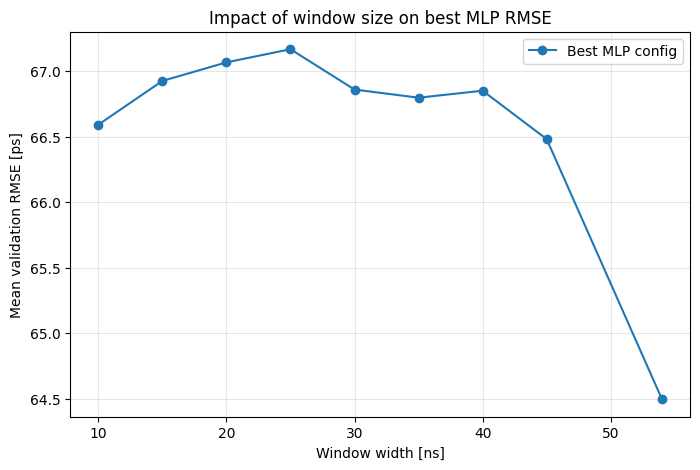

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    mlp_best_by_window["window_width_ns"],
    mlp_best_by_window["mean_validation_rmse"],
    marker="o",
    label="Best MLP config",
)
plt.xlabel("Window width [ns]")
plt.ylabel("Mean validation RMSE [ps]")
plt.title("Impact of window size on best MLP RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
compare = mlp_best_by_window.merge(
    std_best_by_window[["window_id", "window_width_ns", "mean_validation_rmse", "method_name"]],
    on=["window_id", "window_width_ns"],
    suffixes=("_mlp", "_std"),
)

display(compare[[
    "window_id",
    "window_width_ns",
    "config_id",
    "mean_validation_rmse_mlp",
    "method_name",
    "mean_validation_rmse_std",
]])

,window_id,window_width_ns,config_id,mean_validation_rmse_mlp,method_name,mean_validation_rmse_std
0,1,10.0,mlp_001,66.590755,linear_spline,67.786333
1,2,15.0,mlp_001,66.924775,linear_spline,69.330618
2,3,20.0,mlp_001,67.066356,linear_spline,71.459860
3,4,25.0,mlp_001,67.166708,linear_spline,71.050267
4,5,30.0,mlp_001,66.858887,linear_spline,75.763372
5,6,35.0,mlp_001,66.796677,linear_spline,73.584908
6,7,40.0,mlp_001,66.850059,linear_spline,74.372621
7,8,45.0,mlp_001,66.480373,linear_spline,77.589785
8,9,54.0,mlp_001,64.495021,linear_spline,77.619030


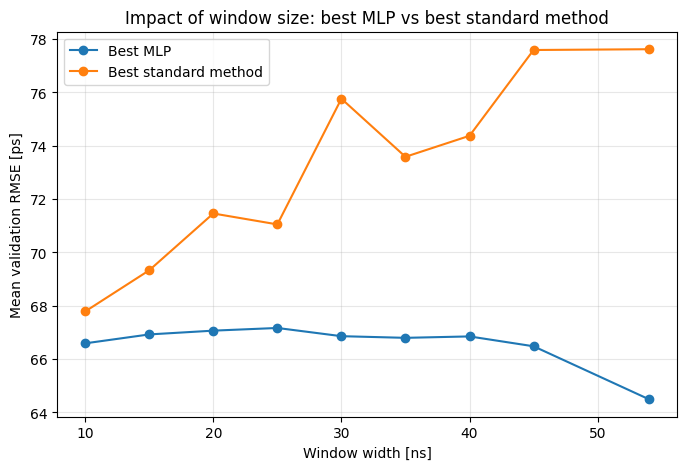

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    compare["window_width_ns"],
    compare["mean_validation_rmse_mlp"],
    marker="o",
    label="Best MLP",
)
plt.plot(
    compare["window_width_ns"],
    compare["mean_validation_rmse_std"],
    marker="o",
    label="Best standard method",
)
plt.xlabel("Window width [ns]")
plt.ylabel("Mean validation RMSE [ps]")
plt.title("Impact of window size: best MLP vs best standard method")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

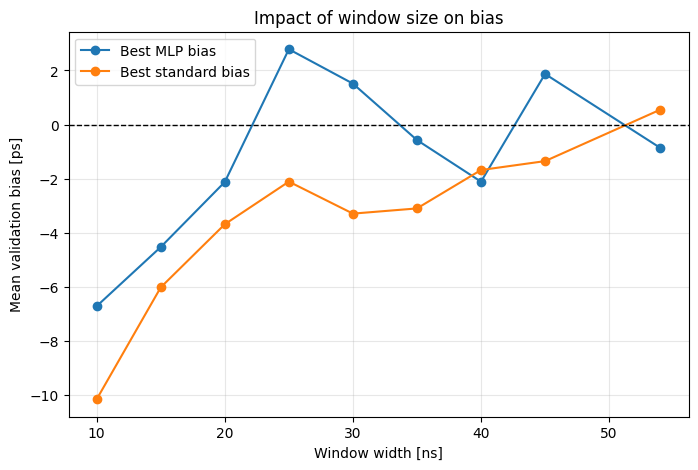

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    mlp_best_by_window["window_width_ns"],
    mlp_best_by_window["mean_validation_bias"],
    marker="o",
    label="Best MLP bias",
)
plt.plot(
    std_best_by_window["window_width_ns"],
    std_best_by_window["mean_validation_bias"],
    marker="o",
    label="Best standard bias",
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Window width [ns]")
plt.ylabel("Mean validation bias [ps]")
plt.title("Impact of window size on bias")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
winner_configs = mlp_best_by_window[["window_id", "config_id", "window_width_ns"]].copy()
display(winner_configs.sort_values("window_width_ns"))

,window_id,config_id,window_width_ns
0,1,mlp_001,10.0
1,2,mlp_001,15.0
2,3,mlp_001,20.0
3,4,mlp_001,25.0
4,5,mlp_001,30.0
5,6,mlp_001,35.0
6,7,mlp_001,40.0
7,8,mlp_001,45.0
8,9,mlp_001,54.0


In [ ]:
summary_table = compare.merge(
    mlp_best_by_window[["window_id", "mean_validation_bias", "mean_validation_ctr"]],
    on="window_id",
    how="left",
).rename(
    columns={
        "config_id": "best_mlp_config",
        "mean_validation_rmse_mlp": "best_mlp_rmse_ps",
        "mean_validation_rmse_std": "best_std_rmse_ps",
        "method_name": "best_std_method",
        "mean_validation_bias": "best_mlp_bias_ps",
        "mean_validation_ctr": "best_mlp_ctr_ps",
    }
)

display(summary_table.sort_values("window_width_ns"))

,window_id,best_mlp_config,best_mlp_rmse_ps,mean_validation_bias_x,mean_validation_ctr_x,mean_best_epoch,runs,window_before_ns,window_after_ns,window_width_ns,best_std_rmse_ps,best_std_method,mean_validation_bias_y,mean_validation_ctr_y
0,1,mlp_001,66.590755,-6.720049,139.482418,79.666667,3,4.0,6.0,10.0,67.786333,linear_spline,-6.720049,139.482418
1,2,mlp_001,66.924775,-4.531961,145.915732,33.666667,3,4.0,11.0,15.0,69.330618,linear_spline,-4.531961,145.915732
2,3,mlp_001,67.066356,-2.125049,144.000778,51.000000,3,4.0,16.0,20.0,71.459860,linear_spline,-2.125049,144.000778
3,4,mlp_001,67.166708,2.786939,151.005989,66.000000,3,4.0,21.0,25.0,71.050267,linear_spline,2.786939,151.005989
4,5,mlp_001,66.858887,1.514300,151.491675,75.000000,3,4.0,26.0,30.0,75.763372,linear_spline,1.514300,151.491675
5,6,mlp_001,66.796677,-0.574252,151.257062,61.333333,3,4.0,31.0,35.0,73.584908,linear_spline,-0.574252,151.257062
6,7,mlp_001,66.850059,-2.114567,148.486694,46.333333,3,4.0,36.0,40.0,74.372621,linear_spline,-2.114567,148.486694
7,8,mlp_001,66.480373,1.871301,145.700203,65.333333,3,4.0,41.0,45.0,77.589785,linear_spline,1.871301,145.700203
8,9,mlp_001,64.495021,-0.865627,139.518376,60.666667,3,4.0,50.0,54.0,77.619030,linear_spline,-0.865627,139.518376


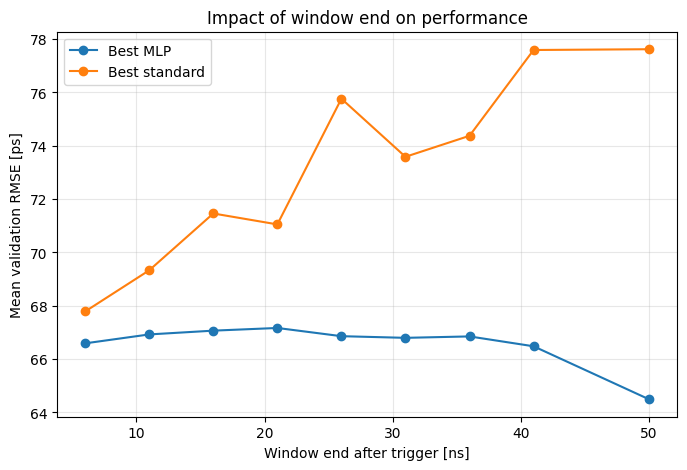

In [ ]:
compare2 = mlp_best_by_window.merge(
    std_best_by_window[["window_id", "window_after_ns", "mean_validation_rmse", "method_name"]],
    on=["window_id", "window_after_ns"],
    suffixes=("_mlp", "_std"),
)

plt.figure(figsize=(8, 5))
plt.plot(compare2["window_after_ns"], compare2["mean_validation_rmse_mlp"], marker="o", label="Best MLP")
plt.plot(compare2["window_after_ns"], compare2["mean_validation_rmse_std"], marker="o", label="Best standard")
plt.xlabel("Window end after trigger [ns]")
plt.ylabel("Mean validation RMSE [ps]")
plt.title("Impact of window end on performance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

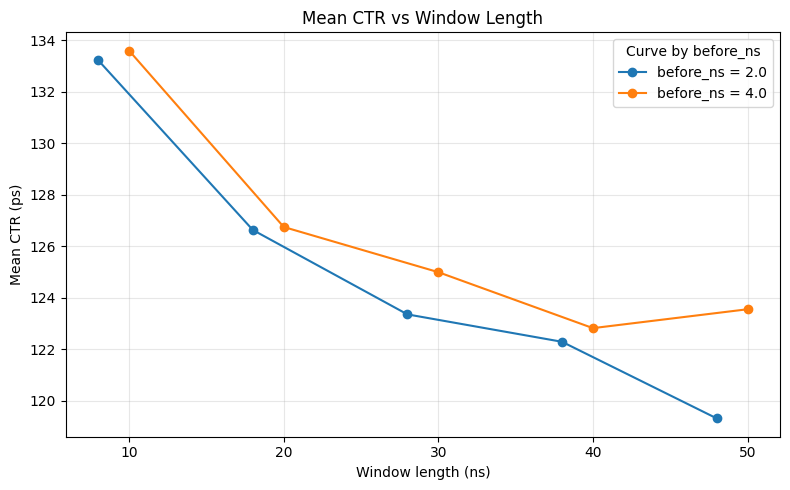

In [ ]:
# Load data
window_df =  pd.read_csv("results/47V/experiments/mlp_window_grid_2/windows.csv")
summary_df =  pd.read_csv("results/47V/experiments/mlp_window_grid_2/summary.csv")

# Merge on window_id
df = summary_df.merge(window_df, on="window_id", how="left")

# Compute window length
df["window_length_ns"] = df["before_ns"] + df["after_ns"]

# Optional: keep only completed entries
if "complete" in df.columns:
    df = df[df["complete"] == 1]

# Plot mean CTR vs window length, grouped by before_ns
plt.figure(figsize=(8, 5))

for before_ns, group in sorted(df.groupby("before_ns")):
    group = group.sort_values("window_length_ns")
    plt.plot(
        group["window_length_ns"],
        group["mean_validation_ctr_ps"],
        marker="o",
        label=f"before_ns = {before_ns}"
    )

plt.xlabel("Window length (ns)")
plt.ylabel("Mean CTR (ps)")
plt.title("Mean CTR vs Window Length")
plt.legend(title="Curve by before_ns")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()